In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix
from sklearn.linear_model import LinearRegression,Lasso, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import KFold, GridSearchCV
from scipy import stats
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, recall_score, accuracy_score

### Question 1 – Communities & Crime

In [23]:
col_names = [
    'state', 'county', 'community', 'communityname', 'fold', 'population', 'householdsize',
    'racepctblack', 'racePctWhite', 'racePctAsian', 'racePctHisp', 'agePct12t21',
    'agePct12t29', 'agePct16t24', 'agePct65up', 'numbUrban', 'pctUrban', 'medIncome',
    'pctWWage', 'pctWFarmSelf', 'pctWInvInc', 'pctWSocSec', 'pctWPubAsst', 'pctWRetire',
    'medFamInc', 'perCapInc', 'whitePerCap', 'blackPerCap', 'indianPerCap', 'AsianPerCap',
    'OtherPerCap', 'HispPerCap', 'NumUnderPov', 'PctPopUnderPov', 'PctLess9thGrade',
    'PctNotHSGrad', 'PctBSorMore', 'PctUnemployed', 'PctEmploy', 'PctEmplManu',
    'PctEmplProfServ', 'PctOccupManu', 'PctOccupMgmtProf', 'MalePctDivorce',
    'MalePctNevMarr', 'FemalePctDiv', 'TotalPctDiv', 'PersPerFam', 'PctFam2Par',
    'PctKids2Par', 'PctYoungKids2Par', 'PctTeen2Par', 'PctWorkMomYoungKids', 'PctWorkMom',
    'NumIlleg', 'PctIlleg', 'NumImmig', 'PctImmigRecent', 'PctImmigRec5', 'PctImmigRec8',
    'PctImmigRec10', 'PctRecentImmig', 'PctRecImmig5', 'PctRecImmig8', 'PctRecImmig10',
    'PctSpeakEnglOnly', 'PctNotSpeakEnglWell', 'PctLargHouseFam', 'PctLargHouseOccup',
    'PersPerOccupHous', 'PersPerOwnOccHous', 'PersPerRentOccHous', 'PctPersOwnOccup',
    'PctPersDenseHous', 'PctHousLess3BR', 'MedNumBR', 'HousVacant', 'PctHousOccup',
    'PctHousOwnOcc', 'PctVacantBoarded', 'PctVacMore6Mos', 'MedYrHousBuilt',
    'PctHousNoPhone', 'PctWOFullPlumb', 'OwnOccLowQuart', 'OwnOccMedVal', 'OwnOccHiQuart',
    'RentLowQ', 'RentMedian', 'RentHighQ', 'MedRent', 'MedRentPctHousInc',
    'MedOwnCostPctInc', 'MedOwnCostPctIncNoMtg', 'NumInShelters', 'NumStreet',
    'PctForeignBorn', 'PctBornSameState', 'PctSameHouse85', 'PctSameCity85',
    'PctSameState85', 'LemasSwornFT', 'LemasSwFTPerPop', 'LemasSwFTFieldOps',
    'LemasSwFTFieldPerPop', 'LemasTotalReq', 'LemasTotReqPerPop', 'PolicReqPerOffic',
    'PolicPerPop', 'RacialMatchCommPol', 'PctPolicWhite', 'PctPolicBlack',
    'PctPolicHisp', 'PctPolicAsian', 'PctPolicMinor', 'OfficAssgnDrugUnits',
    'NumKindsDrugsSeiz', 'PolicAveOTWorked', 'LandArea', 'PopDens', 'PctUsePubTrans',
    'PolicCars', 'PolicOperBudg', 'LemasPctPolicOnPatr', 'LemasGangUnitDeploy',
    'LemasPctOfficDrugUn', 'PolicBudgPerPop', 'ViolentCrimesPerPop'
]

df_original= pd.read_csv("data/communities.data", header=None, names=col_names)

Task A: Dataset Curation and Preprocessing

1. Potential Shortcomings
- The crime data is from 1995, while the demographic and law enforcement data is from 1990. A five-year gap could mean a lot, especially considering potential changes in elected officials.
- For the FBI UCR dataset, we may presume that the denser the police force is, the more likely a crime will be recorded in the database. This bias could hurt the model's ability to show the relationship between the density of police force and the crime rate.
- The dataset itself suffers from data selection bias. For example, some Midwestern communities were filtered out due to the distribution of rape crime data. Also, for the Law
Enforcement Management and Administration Statistics, agencies that have fewer than 100 officers were filtered out. This means the model may not have the ability to predict these cases, and the interpretability of the model is also limited to the cases within the dataset.

2. Preprocessing and Explanations, as follows:

In [24]:
# copy the original dataframe to a new one, so that we do not have to reload the data when we want to try a different preprocessing method.
df = df_original.copy()

# drop duplicates.
df = df.drop_duplicates()

# drop useless columns, as they are not useful for our model.
df = df.drop(columns=['state', 'county', 'community', 'communityname', 'fold'])

# replace ? with NaN and make sure all columns are numeric.
df = df.replace('?', np.nan)
df = df.apply(pd.to_numeric, errors='coerce')

# filter out rows with missing target variable, as we cannot use them for training or testing our model.
df = df[df['ViolentCrimesPerPop'].notna()]

# only keep columsn with less than 50% missing values. There could be a better way to deal with them, but here we just drop them for simplicity.
df = df.loc[:, df.isnull().mean() < 0.5]

# split the data into features and target variable.
X = df.drop('ViolentCrimesPerPop', axis=1)
y = df['ViolentCrimesPerPop']
# here we split the data before impute with MICE, because we want to avoid data leakage. 
# If we impute the whole dataset before splitting, the imputation process will use information from the test set, 
# which can lead to overly optimistic performance estimates. By splitting the data first and then applying MICE separately to the training and test sets, 
# we ensure that the imputation process only uses information from the training set, thus providing a more realistic evaluation of our model's performance on unseen data.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# outlier detection and treatment is put here, as we should only do operation on training set and avoiding operating on test set to prevent data leakage.
# here we use z-score to detect and replce outliers with NaN
z_scores = np.abs((X_train - X_train.mean()) / X_train.std())
X_train = X_train.mask(z_scores > 3, np.nan)

# handle missing value by imputing with MICE. MICE is a more sophisticated imputation method that models each feature with missing values as a function of other features, 
# and iteratively estimates the missing values. This can lead to more accurate imputations compared to simpler methods like mean or median imputation, 
# especially when the data has complex relationships between features.
imputer = IterativeImputer(add_indicator=True).set_output(transform="pandas")
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# There is no need for feature scaling as the original dataset already did this for us.

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


3. feature engineering three features:

In [25]:
# 1) we create an interation term of youth population and unemployment. we presume that the young unemployed people will have a huge effect on the crime rate.
X_train['Youth_Unemployment_Proxy'] = X_train['agePct16t24'] * X_train['PctUnemployed']

# 2) we create an interaction term of poverty and unemployment rate. we suspect that the poor people who are unemployed will have a higher crime rate.
X_train['Poverty_Unemployment_Proxy'] = X_train['PctPopUnderPov'] * X_train['PctUnemployed']

# 3) we create a squared term of the percentage of kids living with both parents, as we suspect that the effect of this variable on the crime rate is not linear,
# and there might be a threshold effect where the crime rate drops significantly when the percentage of kids living with both parents exceeds a certain level.
X_train['PctKids2Par_Squared'] = X_train['PctKids2Par'] ** 2

# applying these three features to test sets.
X_test['Youth_Unemployment_Proxy'] = X_test['agePct16t24'] * X_test['PctUnemployed']
X_test['Poverty_Unemployment_Proxy'] = X_test['PctPopUnderPov'] * X_test['PctUnemployed']
X_test['PctKids2Par_Squared'] = X_test['PctKids2Par'] ** 2

4. Curate the processed data:

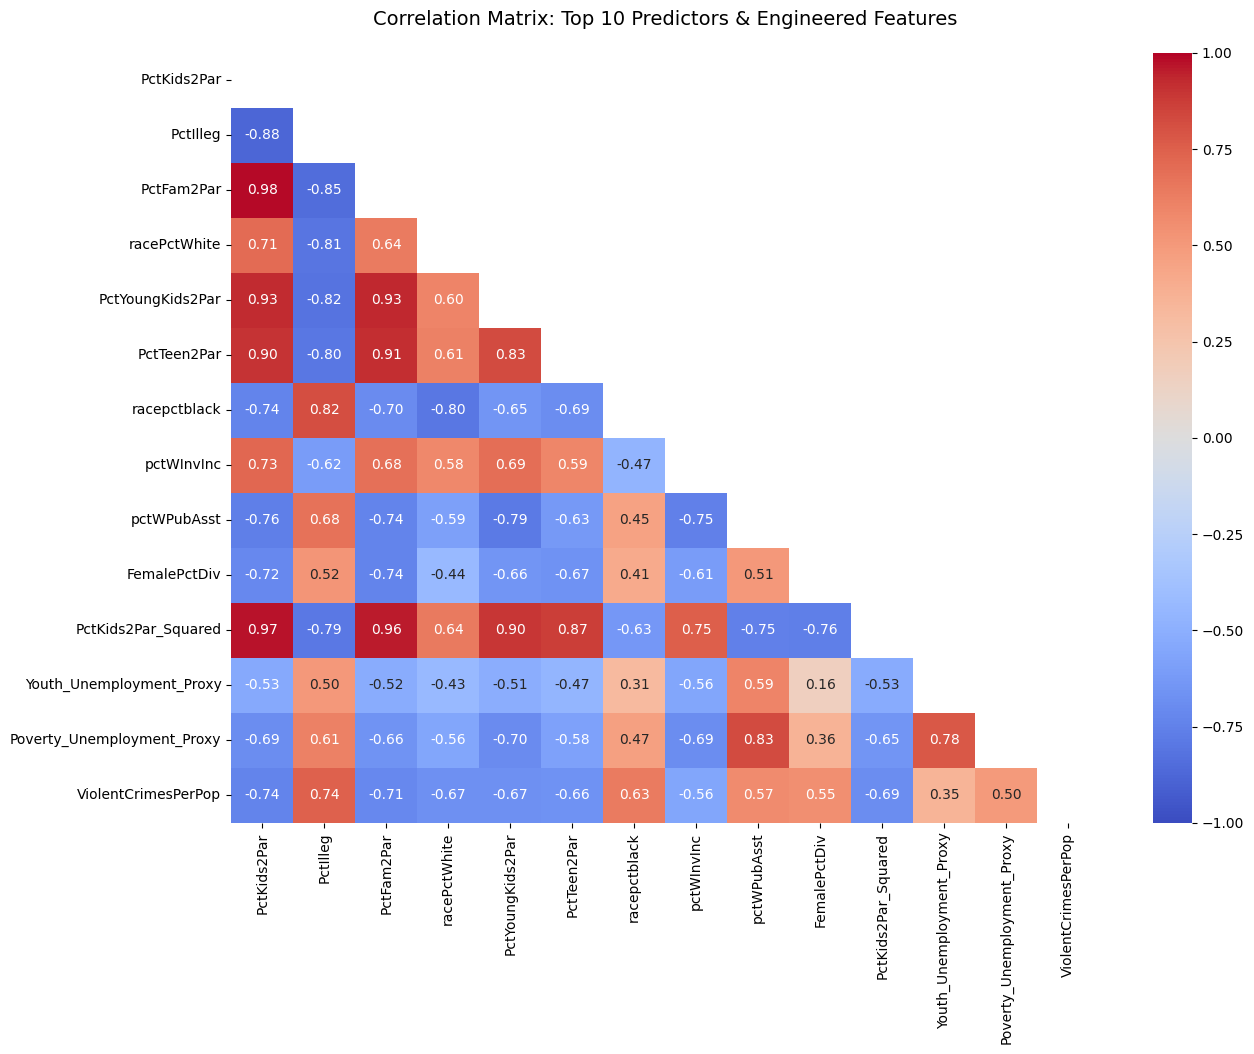

,mean,std,min,50%,max
PctKids2Par,0.615957,0.206465,0.000000,0.6300,0.990000
PctIlleg,0.250750,0.227854,0.000000,0.1700,1.299150
PctFam2Par,0.606700,0.201081,-0.014030,0.6200,0.990000
racePctWhite,0.755314,0.234484,-0.452499,0.8400,1.000000
PctYoungKids2Par,0.661874,0.215558,-0.006184,0.7000,1.000000
PctTeen2Par,0.577574,0.189681,0.009098,0.6000,1.000000
racepctblack,0.180020,0.252309,0.000000,0.0600,1.676259
pctWInvInc,0.493054,0.176711,0.000000,0.4800,1.000000
pctWPubAsst,0.314259,0.212660,0.000000,0.2600,1.054194
FemalePctDiv,0.493527,0.172675,0.000000,0.5100,0.930000


In [26]:
# these features are selected based on Summary Statistics of "Correl" (correlation) in communities.names. We presume a stronger correlation with the target variable could mean that it can offer more information in predicting the latter.
top_features = [
    'PctKids2Par', 'PctIlleg', 'PctFam2Par', 'racePctWhite', 'PctYoungKids2Par', 
    'PctTeen2Par', 'racepctblack', 'pctWInvInc', 'pctWPubAsst', 'FemalePctDiv',
    'PctKids2Par_Squared', 'Youth_Unemployment_Proxy', 'Poverty_Unemployment_Proxy'
]

subset_df = X_train[top_features].copy()
subset_df['ViolentCrimesPerPop'] = y_train

# in this plot, we visualize the correlation matrix of the top 10 predictors and the three engineered features. 
# This can help us understand the relationships between these features and identify any multicollinearity issues.
plt.figure(figsize=(14, 10))
corr_matrix = subset_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix: Top 10 Predictors & Engineered Features", fontsize=14, pad=20)
plt.show()

display(subset_df.describe().T[['mean', 'std', 'min', '50%', 'max']])

Task B: Regression Model Development and Evaluation

1. Model selection.
We adopt regression model here. For the model we have interacted with through course, regression models are more suitbale to deal with target variables that is numbers.
We tried rigid ,lasso and elstic net,and we choose elastic net as it is more flexable and thus have higher adapability comparing with rigid and lasso, especially we do not encounter computational restriction here as the data is simple.

In [27]:
def evaluate_models(X_train, y_train, X_test, y_test):
    # Setup KFold for robust hyperparameter tuning
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    models_config = {
        'Ridge': (
            Ridge(random_state=42),
            {'alpha': [0.01, 0.1, 1.0, 5.0, 10.0]}
        ),
        'Lasso': (
            Lasso(max_iter=10000, tol=1e-3, random_state=42),
            {'alpha': [0.00001, 0.00005, 0.0001, 0.0005, 0.001]}
        ),
        'ElasticNet': (
            ElasticNet(max_iter=10000, tol=1e-3, random_state=42),
            {'alpha': [0.00001, 0.00005, 0.0001, 0.0005, 0.001], 
             'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}
        )
    }
    
    results = []
    
    for name, (model, params) in models_config.items():
        grid = GridSearchCV(model, params, cv=kf, scoring='r2')
        grid.fit(X_train, y_train)
        
        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test)
        
        r2 = r2_score(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        
        results.append({
            'Model': name,
            'Best Params': str(grid.best_params_),
            'Test R2': round(r2, 4),
            'Test MSE': round(mse, 4)
        })
    
    return pd.DataFrame(results).sort_values(by='Test R2', ascending=False).reset_index(drop=True)

results_df = evaluate_models(X_train, y_train, X_test, y_test)

display(results_df)

,Model,Best Params,Test R2,Test MSE
0,Ridge,{'alpha': 5.0},0.6424,0.0171
1,Lasso,{'alpha': 0.0005},0.6421,0.0171
2,ElasticNet,"{'alpha': 0.0005, 'l1_ratio': 0.9}",0.6411,0.0172


2. Discretize the target and Fit two distinct classifiers.
- Here I discretize the crime into high crime and low crime. For what is the criteria for a high crime rate, I consider figuring this out as a relative rather than absolute, as relative crime rate can be taken into consideration the culture of US society or other latent variables that affect crime. here I specifically take the top 25% as a high crime area, supported by The Pinkerton Crime Index.
- From the experiment below, Decision Tree performs better, because here we use about 100 features, which is high dimension, making the distance calculation of KNN being less effective in our case.

In [28]:
def build_and_evaluate_classifiers(X_train, y_train, X_test, y_test):
    # the top 25% is high crime.
    threshold = y_train.quantile(0.75)
    
    # Convert continuous targets to integers (1 = High Crime, 0 = Low Crime)
    y_train_class = (y_train >= threshold).astype(int)
    y_test_class = (y_test >= threshold).astype(int)

    # still use k-fold for robust hyperparameter tuning.
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    models_config = {
        'Decision Tree': (
            DecisionTreeClassifier(random_state=42),
            {'max_depth': [3, 5, 7, 10], 'min_samples_split': [2, 5, 7, 10], 'criterion': ['gini', 'entropy']}
        ),
        'K-Nearest Neighbors': (
            KNeighborsClassifier(),
            {'n_neighbors': [3, 5, 7, 11, 15], 'weights': ['uniform', 'distance']}
        )
    }

    results = []
    best_models = {}
    
    for name, (model, params) in models_config.items():
        # Fit the model using F1-score optimization
        grid = GridSearchCV(model, params, cv=kf, scoring='f1')
        grid.fit(X_train, y_train_class)
        
        best_model = grid.best_estimator_
        best_models[name] = best_model
        
        y_pred = best_model.predict(X_test)
        
        f1 = f1_score(y_test_class, y_pred)
        recall = recall_score(y_test_class, y_pred)
        accuracy = accuracy_score(y_test_class, y_pred)

        conf_matrix = confusion_matrix(y_test_class, y_pred)

        results.append({
            'Model': name,
            'Best Params': str(grid.best_params_),
            'Test F1': round(f1, 4),
            'Test Recall': round(recall, 4),
            'Test Accuracy': round(accuracy, 4)
        })
        
    results_df = pd.DataFrame(results).sort_values(by='Test F1', ascending=False).reset_index(drop=True)

    return best_models, results_df, conf_matrix

trained_classifiers, classification_results_df, conf_matrix_output = build_and_evaluate_classifiers(X_train, y_train, X_test, y_test)

display(classification_results_df)

print("Confusion Matrix:\n", conf_matrix_output)

,Model,Best Params,Test F1,Test Recall,Test Accuracy
0,Decision Tree,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.6690,0.6419,0.8431
1,K-Nearest Neighbors,"{'n_neighbors': 11, 'weights': 'distance'}",0.6353,0.5473,0.8447


Confusion Matrix:
 [[425  26]
 [ 67  81]]


3. As shown by the hyperparameter tuning process in steps 1 and 2, I tried multiple hyperparameters on the same model. This helps in finding the best hyperparameters that are able to capture the patterns of the features. With hyperparameter tuning, the model performance reached an acceptable level, where the R² for the regression model is about 0.65 and the F1 score for the classification model is about 0.65. We can notice from the confusion matrix that the DT model performs not that satisfying on recall, which is within expectation as there is less observation for the high crime rate and thus the model is bad at predicting it as it cannot learn enough of its pattern.


4. Evaluating model. Here we pick the best performed EN and DT in each task for comparison.
- Fitness. Fitness cannot be directly compared here as for the regression model it is dealing with continuous variables, while for a classification model it is dealing with discrete variables. the criteria of choosing here thus depends on the task. For example, if I want to find out the feature that has the most impact on crime rate, then i will use the result of EN as it offers smaller granularity (by the way this also makes the model have a lower fit, as its target variable contains more information).
- variance/bias relationship. EN has higher bias but lower variance inherently, while DT has higher variance but lower bias. The choice thus also depends on the task. For example, for predicting purpose, the second model is preferred as it is able to capture more detail of the data.

We like the EN model as we care more about explaining rather than predicting.

Task C: Methodological & Substantive Implications

1. We are dissatisfied with our final results, as the R2 for the regression model is lower than 70% and the F1 score for the classification model is also lower than 0.7. We believe there is room for improvement. We encountered the following problems:
- There were too many features to consider one by one to figure out which interaction terms to add (or to further assess the effect of the interaction terms).
- The data is not well-balanced after discretization, but if we do not discretize in this way, the target variable will make less sense.

2.
- Disadvantages: We simply used MICE and filtered out features with more than 50% missing values. This could be treated more carefully, as there might be a systematic pattern to the missing values. Furthermore, we did not conduct feature compression like PCA, which may make the model perform worse as it relies more on perhaps useless features.
- Advantages: The benefit is that we made the model interpretable. We did not draw complicated assumptions, and not using PCA preserves the interpretability of the model.

3.
- Firstly, We would enrich the data by including more features and finding crime data that is closer to the time the demographic survey was conducted. We would also start to consider a time scale, as the current static observation seems insufficient.
- Secondly, We would take the racial equity factor into consideration if We were applying this model in social welfare allocation.

4. This model could be used for explanatory purposes in policy decisions, for example, deciding where to allocate social aid resources. However, this cannot be used for predicting the allocation of police resources. There is endogeneity involved: more police deployed will also increase the amount of crime found, thus resulting in a bias away from communities that genuinely need police.

5.
- More police does not mean more crime, as the "crime rate" here only reflects crimes being reported. This also means we cannot apply it to police resource allocation because the target variable is simply not the true crime rate.
- Regarding racial equity issues, even if we filter out race data features, other factors will still contain related proxy information, making racial equity hard to achieve. This is also unfair because these factors are shaped by historical context; if we do not deal with them properly, we are simply hurting these groups again.
- The causal relationship is not clear in this case. What is clear is the correlation. Thus, there would be much more work to do if we wanted to collect proof for a causal theory.

### Question 2 – Tezpur University Android Malware Dataset

workflow：
- Load data
- EDA - distribution of the target variable
- Identify potential issues - imbalance.
- training & testing 
- models and hyperparameters.
- Evaluate model performance
- Interpret

In [36]:
#load data
df_original=pd.read_csv("data/TUANDROMD.csv")
df_original

,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,...,Landroid/telephony/TelephonyManager;->getLine1Number,Landroid/telephony/TelephonyManager;->getNetworkOperator,Landroid/telephony/TelephonyManager;->getNetworkOperatorName,Landroid/telephony/TelephonyManager;->getNetworkCountryIso,Landroid/telephony/TelephonyManager;->getSimOperator,Landroid/telephony/TelephonyManager;->getSimOperatorName,Landroid/telephony/TelephonyManager;->getSimCountryIso,Landroid/telephony/TelephonyManager;->getSimSerialNumber,Lorg/apache/http/impl/client/DefaultHttpClient;->execute,Label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,malware
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,malware
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,malware
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,malware
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,malware
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4460,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,goodware
4461,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,goodware
4462,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,goodware
4463,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,goodware


Task A: Dataset Curation and Preprocessing

In [62]:
#Check target distribution
df_original['Label'].value_counts(dropna=False)

#The dataset shows class imbalance, with malware samples significantly outnumbering benign applications.

Label
1.0    3565
0.0     899
Name: count, dtype: int64

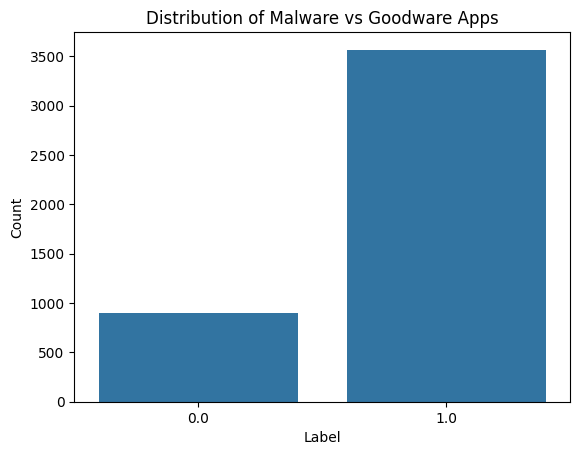

In [65]:
# plot label distribution
sns.countplot(x='Label', data=df_original)
plt.title("Distribution of Malware vs Goodware Apps")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

#malware samples dominate the dataset

The distribution of the target variable shows a clear class imbalance. 
There are significantly more malware samples (label = 1) than benign applications (label = 0). 
This imbalance could potentially bias machine learning models toward predicting the majority class. 
Therefore, stratified sampling is used during the train-test split to preserve the class distribution in both datasets.

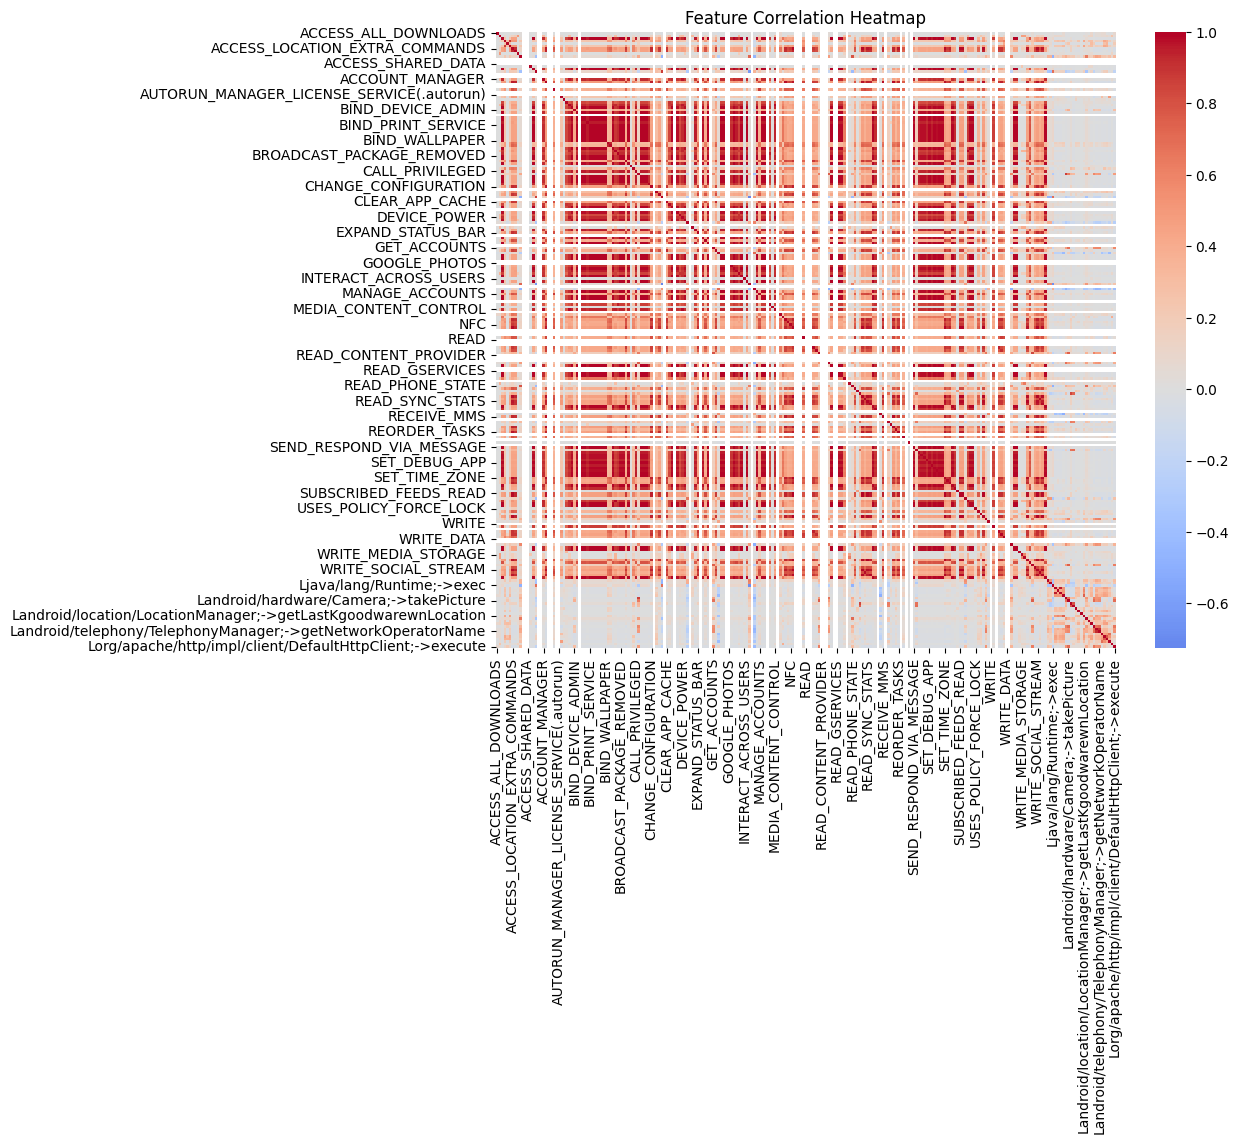

In [99]:
# Explore feature correlations
corr_matrix = X.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

To better understand relationships between features, a correlation heatmap was generated. 
Many of the Android permission features show moderate positive correlations with each other. 
This is expected because certain permissions are often requested together by applications. 
However, the correlations are not perfectly strong across all features, suggesting that different permissions still provide distinct information that may help machine learning models distinguish between malware and benign applications.

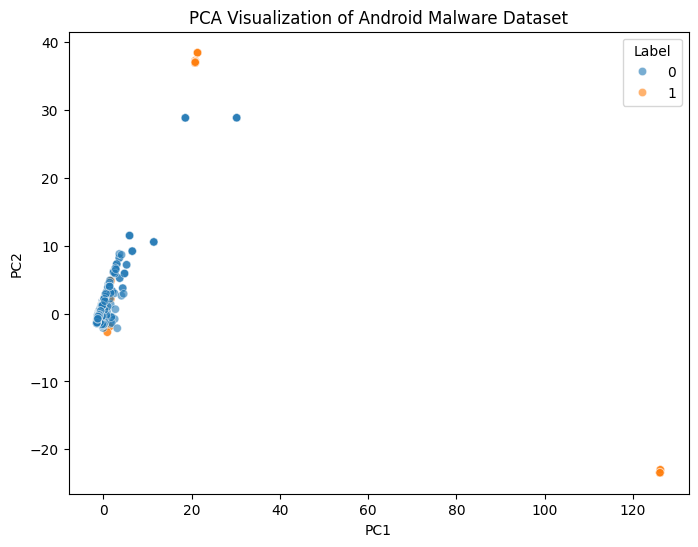

In [101]:
#pca
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#dimensionality exploration
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame()
pca_df["PC1"] = X_pca[:,0]
pca_df["PC2"] = X_pca[:,1]
pca_df["Label"] = y.values

plt.figure(figsize=(8,6))
sns.scatterplot(x="PC1", y="PC2", hue="Label", data=pca_df, alpha=0.6)
plt.title("PCA Visualization of Android Malware Dataset")
plt.show()

PCA was applied to reduce the high-dimensional feature space into two components for visualization. 
The scatter plot shows some separation between malware and benign applications, although the two classes still overlap in several areas. 
This suggests that while the dataset contains patterns useful for classification, the decision boundary is not completely linear, which supports the use of more flexible models such as Random Forest.

In [103]:
#Check missing values
df_original.isnull().sum().sum()

np.int64(0)

Missing values were examined across the dataset. 
Only one missing value was found in the label column, which was removed from the dataset. 
Since the features represent binary permission indicators, missing feature values were filled with 0, representing the absence of that permission.

In [102]:
# see which columns have missing values
df_original.isnull().sum().sort_values(ascending=False).head(10)

ACCESS_ALL_DOWNLOADS              0
ACCESS_CACHE_FILESYSTEM           0
ACCESS_CHECKIN_PROPERTIES         0
ACCESS_COARSE_LOCATION            0
ACCESS_COARSE_UPDATES             0
ACCESS_FINE_LOCATION              0
ACCESS_LOCATION_EXTRA_COMMANDS    0
ACCESS_MOCK_LOCATION              0
ACCESS_MTK_MMHW                   0
ACCESS_NETWORK_STATE              0
dtype: int64

The dataset primarily consists of binary permission indicators, so no complex feature transformations were required. 
After cleaning the label column and ensuring all features were numeric, the dataset was ready for model training. 
Missing feature values were replaced with 0, which is reasonable because permissions are binary indicators 
where absence naturally corresponds to 0.


In [68]:
# there is one missing value in Label, so drop that row
df_original = df_original.dropna(subset=['Label'])

# check again
df_original['Label'].isnull().sum()

np.int64(0)

In [70]:
# Convert Label to binary
if df_original['Label'].dtype == 'object':
    df_original['Label'] = df_original['Label'].astype(str).str.strip().str.lower()
    df_original['Label'] = df_original['Label'].map({'goodware': 0, 'malware': 1})

# numeric
df_original['Label'] = pd.to_numeric(df_original['Label'], errors='coerce')

# if something weird still remains, drop it
df_original = df_original.dropna(subset=['Label'])

# convert to int
df_original['Label'] = df_original['Label'].astype(int)
df_original['Label'].value_counts(dropna=False)

Label
1    3565
0     899
Name: count, dtype: int64

In [73]:
# Define X and y
X = df_original.drop('Label', axis=1)
y = df_original['Label']

# make sure all features are numeric
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(0)

print("Missing  X:", X.isnull().sum().sum())
print("Missing  y:", y.isnull().sum())
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Missing  X: 0
Missing  y: 0
Shape of X: (4464, 241)
Shape of y: (4464,)


In [74]:
# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts(normalize=True))
print("y_test distribution:")
print(y_test.value_counts(normalize=True))

X_train shape: (3124, 241)
X_test shape: (1340, 241)
y_train distribution:
Label
1    0.798656
0    0.201344
Name: proportion, dtype: float64
y_test distribution:
Label
1    0.798507
0    0.201493
Name: proportion, dtype: float64


The dataset was split into training and testing sets using a 70/30 ratio. 
Stratified sampling was used to ensure that the class imbalance between malware and benign apps 
is preserved in both the training and test sets. 
This helps prevent biased evaluation results.

In [ ]:
-

Task B: Classification Techniques & Analysis

workflow: 
- Logistic Regression & Random Forest
- compare and analysis



Logistic Regression is used as a baseline classifier for this binary classification problem. 
It is simple, interpretable, and widely used for malware detection tasks.

Random Forest is selected as the second model because tree-based models can capture nonlinear 
relationships and interactions between features. Since Android permission data is high-dimensional, 
Random Forest may better capture complex patterns than linear models.

In [104]:
#model 1. Logistic Regression 

from sklearn.linear_model import LogisticRegression

#train Logistic Regression，use the training set to learn how to classsify malware and goodware 
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [76]:
# make predictions
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

After fitting the model on the training set, we use the test set to evaluate how well the model generalizes to unseen applications.

In [90]:
# evaluate logistic regression
print("Logistic Regression Results")
print("Accuracy:", round(accuracy_score(y_test, y_pred_log), 4))
print("Precision:", round(precision_score(y_test, y_pred_log), 4))
print("Recall:", round(recall_score(y_test, y_pred_log), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_log), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_log), 4))

Logistic Regression Results
Accuracy: 0.9836
Precision: 0.9888
Recall: 0.9907
F1 Score: 0.9897
ROC-AUC: 0.9975


In [89]:
#evaluate using precision, recall, F1-score, AUC-ROC

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       270
           1       0.99      0.99      0.99      1070

    accuracy                           0.98      1340
   macro avg       0.98      0.97      0.97      1340
weighted avg       0.98      0.98      0.98      1340



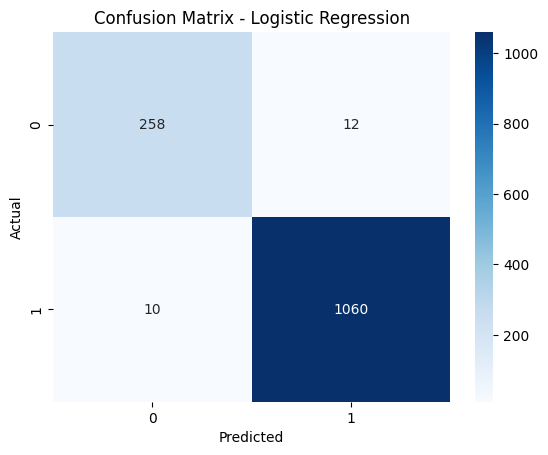

In [60]:
#draw confusion matrix
cm = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

Logistic Regression provides a strong baseline. The model correctly classifies most malware and benign apps, and it produces very few false negatives, which is especially important in security-related classification tasks.

In [94]:
# Model 2: Random Forest
#it can capture nonlinear patterns and interactions across a high-dimensional permission dataset.
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


For the Random Forest model, the number of trees was set to 200 to improve model stability 
and reduce variance. The class_weight parameter was set to "balanced" to address the class 
imbalance between malware and benign applications.

In [83]:
# make predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [84]:
# evaluate random forest
print("Random Forest Results")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("Recall:", round(recall_score(y_test, y_pred_rf), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_rf), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_rf), 4))

Random Forest Results
Accuracy: 0.994
Precision: 0.9972
Recall: 0.9953
F1 Score: 0.9963
ROC-AUC: 0.9991


Multiple evaluation metrics were used to assess model performance. 
Accuracy provides an overall measure of correct predictions, while precision and recall 
capture how well the model identifies malware without producing excessive false alarms. 
The F1 score balances precision and recall, and ROC-AUC evaluates the model's ability 
to distinguish between malware and benign applications across different thresholds.

In [85]:
# detailed report
print(classification_report(y_test, y_pred_rf, target_names=['goodware', 'malware']))

              precision    recall  f1-score   support

    goodware       0.98      0.99      0.99       270
     malware       1.00      1.00      1.00      1070

    accuracy                           0.99      1340
   macro avg       0.99      0.99      0.99      1340
weighted avg       0.99      0.99      0.99      1340



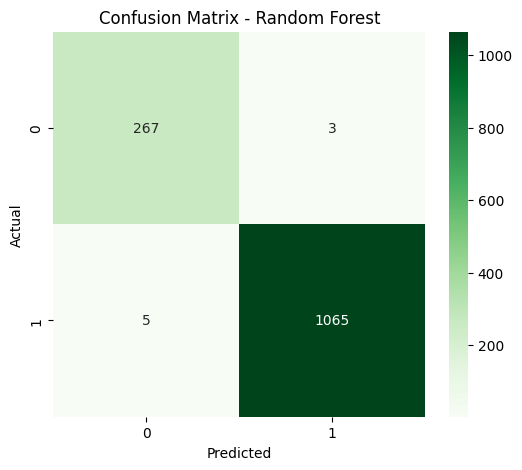

In [87]:
# confusion matrix 
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

The model correctly classifies most applications. Only 5 malware samples are incorrectly classified as benign (false negatives). In malware detection, minimizing false negatives is critical because missing malicious software can cause significant security risks.

In [91]:
# Compare both models
results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results_df = results_df.round(4)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9836,0.9888,0.9907,0.9897,0.9975
1,Random Forest,0.9940,0.9972,0.9953,0.9963,0.9991


Random Forest performs slightly better across all metrics compared to Logistic Regression. 
This suggests that nonlinear relationships between Android permissions may exist, which 
tree-based models are better able to capture.

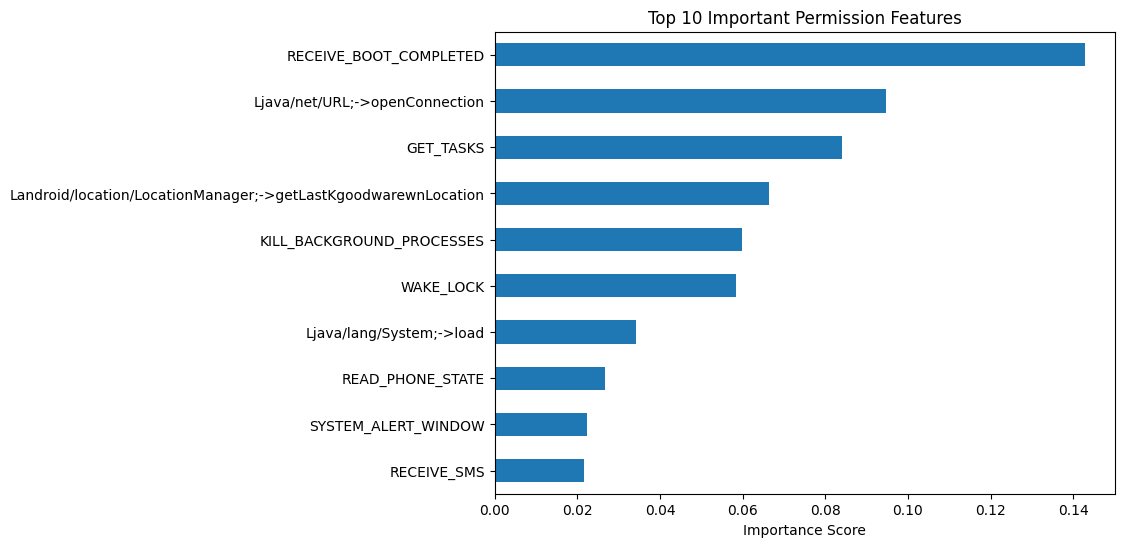

In [97]:
#  Interpret

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,6))
feature_importance.head(10).sort_values().plot(kind='barh')
plt.title("Top 10 Important Permission Features")
plt.xlabel("Importance Score")
plt.show()

the Android permissions that are most useful for distinguishing malware from benign apps. 
Permissions such as RECEIVE_BOOT_COMPLETED, READ_PHONE_STATE, and RECEIVE_SMS allow apps to access sensitive information or run automatically in the background, which are behaviors often associated with malware. 


In malware detection, recall is particularly important because failing to detect malicious 
applications (false negatives) can pose significant security risks. Therefore, minimizing 
false negatives is often more critical than maximizing precision.

Feature importance analysis from the Random Forest model highlights several permissions 
that strongly contribute to malware detection. Permissions such as RECEIVE_BOOT_COMPLETED, 
READ_PHONE_STATE, and RECEIVE_SMS allow applications to access sensitive system resources 
or run automatically in the background, which are behaviors often associated with malicious software.

This suggests that permission-based features provide meaningful signals for identifying 
potentially harmful applications.

### Final Discussion:

Overall, both Logistic Regression and Random Forest achieve very strong performance on the dataset. 
Random Forest performs slightly better across all evaluation metrics, suggesting that nonlinear 
models may capture complex interactions between Android permission features more effectively.

One challenge encountered during this analysis was the high dimensionality of the permission 
features, which can make interpretation more difficult. However, feature importance analysis 
helps identify which permissions contribute most to malware detection.

Although the models perform well on this dataset, real-world deployment would require 
further validation using more diverse datasets and potentially dynamic behavioral features, 
since static permission-based features alone may not capture all forms of malicious behavior.